# 08 solve the capacitated model

Solves the capacitated maximal covering problem to optimality with CBC, for
two objectives across a range of budgets.

Functioning points enter fixed and use no budget; k of the candidates are
selected for repair. Demand is allocated to points subject to capacity, so the
objective measures the population that can actually be served rather than the
population living within reach.

The efficiency objective weights every person equally. The equity objective
weights each cell by the under five share of its subcounty.

Writes `solutions.csv`.

In [1]:
import sys
from pathlib import Path

# config.py sits beside the notebooks, so the working directory is enough. If a
# notebook is run from elsewhere, walk up until it is found.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "config.py").exists())
sys.path.insert(0, str(ROOT))
from config import *


## 1. Inputs

In [2]:
import time
from collections import defaultdict

import numpy as np
import pandas as pd
import pulp
from scipy import sparse

TIME_LIMIT = 1800        # seconds per solve

demand = pd.read_csv(DEMAND_CELLS)
cand = pd.read_csv(KIKUUBE_CAND)
supp = pd.read_csv(KIKUUBE_SUPPLY)
A_cand = sparse.load_npz(REACH_CAND).tocsr()
A_supp = sparse.load_npz(REACH_SUPP).tocsr()

nD, nC, nS = len(demand), len(cand), len(supp)
assert A_cand.shape == (nC, nD) and A_supp.shape == (nS, nD), "matrix shape mismatch"

pop = demand["pop"].values
w_u5 = demand["share_under5"].values
print(f"demand {nD:,}, candidates {nC}, supply {nS}")

demand 100,619, candidates 320, supply 1209


## 2. Capacity

The capacity field is a design assumption recorded in the inventory, not a
measured yield. Where it is missing the median is used, which is 300 for
handpumps in Uganda.

In [3]:
capC = pd.to_numeric(cand.usage_capacity, errors="coerce")
capS = pd.to_numeric(supp.usage_capacity, errors="coerce")
print(f"candidate capacity missing for {capC.isna().sum()} of {nC}")
print(f"supply capacity missing for    {capS.isna().sum()} of {nS}")

capC = capC.fillna(capC.median()).values
capS = capS.fillna(capS.median()).values
print(f"\ncandidate capacity total {capC.sum():,.0f} persons")
print(f"supply capacity total    {capS.sum():,.0f} persons")
print(f"demand population        {pop.sum():,.0f} persons")

candidate capacity missing for 0 of 320
supply capacity missing for    15 of 1209

candidate capacity total 90,350 persons
supply capacity total    339,350 persons
demand population        240,144 persons


## 3. Coverage lists

The solver needs, for each demand cell, the points that can reach it. That is
the transpose of the stored matrices.

In [4]:
cov_c = defaultdict(list)
cov_s = defaultdict(list)
Ac = A_cand.tocoo()
As = A_supp.tocoo()
for j, i in zip(Ac.row, Ac.col):
    cov_c[i].append(j)
for j, i in zip(As.row, As.col):
    cov_s[i].append(j)

print(f"allocation variables, candidates {A_cand.nnz:,}, supply {A_supp.nnz:,}")
print(f"total {A_cand.nnz + A_supp.nnz:,}")

allocation variables, candidates 64,998, supply 320,519
total 385,517


## 4. The model

In [5]:
def solve(K, weight, time_limit=TIME_LIMIT):
    """Capacitated MCLP. K candidates may be repaired; functioning points are free.

    max   sum_ij w_i z_ij
    s.t.  sum_j z_ij <= p_i          a cell is not served more than once over
          sum_i z_ij <= c_j y_j      a repaired point absorbs at most its capacity
          sum_i z_ij <= c_j          a functioning point likewise, with no y
          sum_j y_j  <= K
    """
    p = pulp.LpProblem("CMCLP", pulp.LpMaximize)
    y = {j: pulp.LpVariable(f"y{j}", cat="Binary") for j in range(nC)}

    zc, zs = {}, {}
    for i in range(nD):
        for j in cov_c[i]:
            zc[(i, j)] = pulp.LpVariable(f"c{i}_{j}", lowBound=0)
        for j in cov_s[i]:
            zs[(i, j)] = pulp.LpVariable(f"s{i}_{j}", lowBound=0)

    p += (pulp.lpSum(weight[i] * zc[(i, j)] for (i, j) in zc)
          + pulp.lpSum(weight[i] * zs[(i, j)] for (i, j) in zs))

    for i in range(nD):
        terms = [zc[(i, j)] for j in cov_c[i]] + [zs[(i, j)] for j in cov_s[i]]
        if terms:
            p += pulp.lpSum(terms) <= pop[i]

    bc, bs = defaultdict(list), defaultdict(list)
    for (i, j), v in zc.items():
        bc[j].append(v)
    for (i, j), v in zs.items():
        bs[j].append(v)
    for j in range(nC):
        if bc[j]:
            p += pulp.lpSum(bc[j]) <= capC[j] * y[j]
    for j in range(nS):
        if bs[j]:
            p += pulp.lpSum(bs[j]) <= capS[j]

    p += pulp.lpSum(y.values()) <= K

    p.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit))

    chosen = sorted(j for j in range(nC) if y[j].value() and y[j].value() > 0.5)
    served = (sum(v.value() for v in zc.values())
              + sum(v.value() for v in zs.values()))
    u5 = (sum(w_u5[i] * zc[(i, j)].value() for (i, j) in zc)
          + sum(w_u5[i] * zs[(i, j)].value() for (i, j) in zs))
    return pulp.LpStatus[p.status], chosen, served, u5

## 5. Baseline

With no repairs the model allocates demand to functioning points alone. Every
later figure is a gain over this.

In [6]:
t0 = time.time()
status, _, base_served, base_u5 = solve(0, np.ones(nD))
print(f"baseline, functioning points only: {status}")
print(f"  served {base_served:,.0f} of {pop.sum():,.0f} "
      f"({base_served / pop.sum():.1%} of rural demand)")
print(f"  unserved {pop.sum() - base_served:,.0f}")
print(f"  [{time.time() - t0:.0f}s]")

baseline, functioning points only: Optimal
  served 171,138 of 240,144 (71.3% of rural demand)
  unserved 69,006
  [16s]


In [7]:
# --- allocation snapshot at the baseline, for the gap map ---
def solve_with_alloc(K, weight, time_limit=TIME_LIMIT):
    p = pulp.LpProblem("CMCLP", pulp.LpMaximize)
    y = {j: pulp.LpVariable(f"y{j}", cat="Binary") for j in range(nC)}
    zc, zs = {}, {}
    for i in range(nD):
        for j in cov_c[i]: zc[(i, j)] = pulp.LpVariable(f"c{i}_{j}", lowBound=0)
        for j in cov_s[i]: zs[(i, j)] = pulp.LpVariable(f"s{i}_{j}", lowBound=0)
    p += (pulp.lpSum(weight[i]*v for (i, j), v in zc.items())
          + pulp.lpSum(weight[i]*v for (i, j), v in zs.items()))
    for i in range(nD):
        t = [zc[(i, j)] for j in cov_c[i]] + [zs[(i, j)] for j in cov_s[i]]
        if t: p += pulp.lpSum(t) <= pop[i]
    bc, bs = defaultdict(list), defaultdict(list)
    for (i, j), v in zc.items(): bc[j].append(v)
    for (i, j), v in zs.items(): bs[j].append(v)
    for j in range(nC):
        if bc[j]: p += pulp.lpSum(bc[j]) <= capC[j]*y[j]
    for j in range(nS):
        if bs[j]: p += pulp.lpSum(bs[j]) <= capS[j]
    p += pulp.lpSum(y.values()) <= K
    p.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit))
    served_cell = np.zeros(nD)
    for (i, j), v in zc.items():
        if v.value(): served_cell[i] += v.value()
    for (i, j), v in zs.items():
        if v.value(): served_cell[i] += v.value()
    load_s = np.zeros(nS)
    for (i, j), v in zs.items():
        if v.value(): load_s[j] += v.value()
    chosen = sorted(j for j in range(nC) if y[j].value() and y[j].value() > 0.5)
    return served_cell, load_s, chosen

base_cell, base_load, _ = solve_with_alloc(0, np.ones(nD))
unmet = pop - base_cell
print(f"unmet {unmet.sum():,.0f}")

unmet 69,006


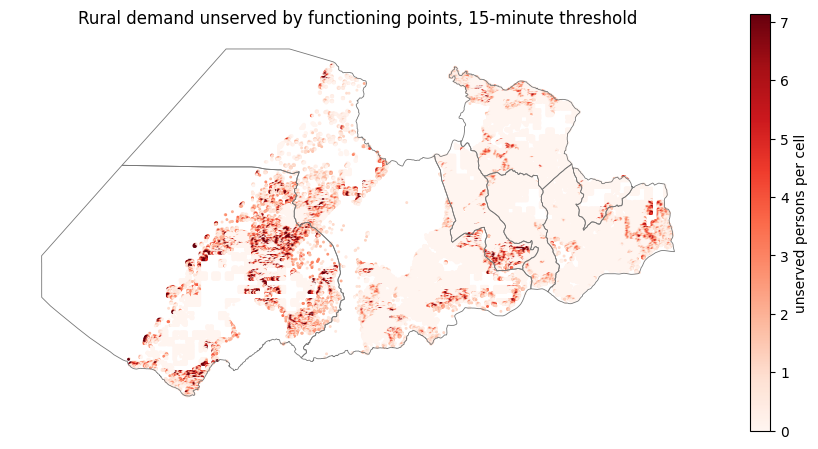

In [8]:
import matplotlib.pyplot as plt
import geopandas as gpd

fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(demand.lon, demand.lat, c=unmet, s=1.2,
                cmap="Reds", vmin=0, vmax=np.percentile(unmet[unmet > 0], 95))
sub_g = gpd.read_file(SUBCOUNTY_GJ).to_crs(CRS_GEO)
sub_g.boundary.plot(ax=ax, color="#777", linewidth=0.6)
plt.colorbar(sc, ax=ax, label="unserved persons per cell", shrink=0.8)
ax.set_title("Rural demand unserved by functioning points, 15-minute threshold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG / "fig_baseline_gap.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Solve

Written after every solve so that an interrupted run loses nothing.

In [12]:
import pandas as pd
print(pd.read_csv(SOLUTIONS))

    k   objective   status         served         gain   u5_weighted  \
0   5  efficiency  Optimal  172637.984044  1499.999998  29009.600346   
1   5      equity  Optimal  172637.984047  1500.000001  29016.030526   
2  10  efficiency  Optimal  174137.984045  2999.999999  29261.969308   
3  10      equity  Optimal  174137.984045  2999.999999  29269.481376   
4  20  efficiency  Optimal  177027.251265  5889.267219  29747.427217   
5  20      equity  Optimal  177027.251264  5889.267218  29749.834856   

   capacity_selected  seconds  \
0             1500.0       66   
1             1500.0       75   
2             3000.0       75   
3             3000.0       98   
4             5950.0      125   
5             5950.0      125   

                                              chosen  
0                             [6, 42, 124, 141, 167]  
1                          [108, 141, 167, 214, 314]  
2      [6, 30, 42, 54, 103, 108, 124, 141, 167, 281]  
3     [6, 42, 54, 103, 108, 141, 167, 214, 

In [11]:
records = []
for K in K_LIST:
    for name, w in [("efficiency", np.ones(nD)), ("equity", w_u5)]:
        t0 = time.time()
        st, chosen, served, u5 = solve(K, w)
        records.append(dict(k=K, objective=name, status=st, served=served,
                            gain=served - base_served, u5_weighted=u5,
                            capacity_selected=float(capC[chosen].sum()),
                            seconds=round(time.time() - t0),
                            chosen=chosen))
        print(f"k={K:3d} {name:10s} {st:8s} served {served:10,.0f} "
              f"(+{served - base_served:7,.0f})  [{time.time() - t0:.0f}s]")
        pd.DataFrame(records).to_csv(SOLUTIONS, index=False)

df = pd.DataFrame(records)

k=  5 efficiency Optimal  served    172,638 (+  1,500)  [66s]
k=  5 equity     Optimal  served    172,638 (+  1,500)  [75s]
k= 10 efficiency Optimal  served    174,138 (+  3,000)  [75s]
k= 10 equity     Optimal  served    174,138 (+  3,000)  [98s]
k= 20 efficiency Optimal  served    177,027 (+  5,889)  [125s]
k= 20 equity     Optimal  served    177,027 (+  5,889)  [125s]


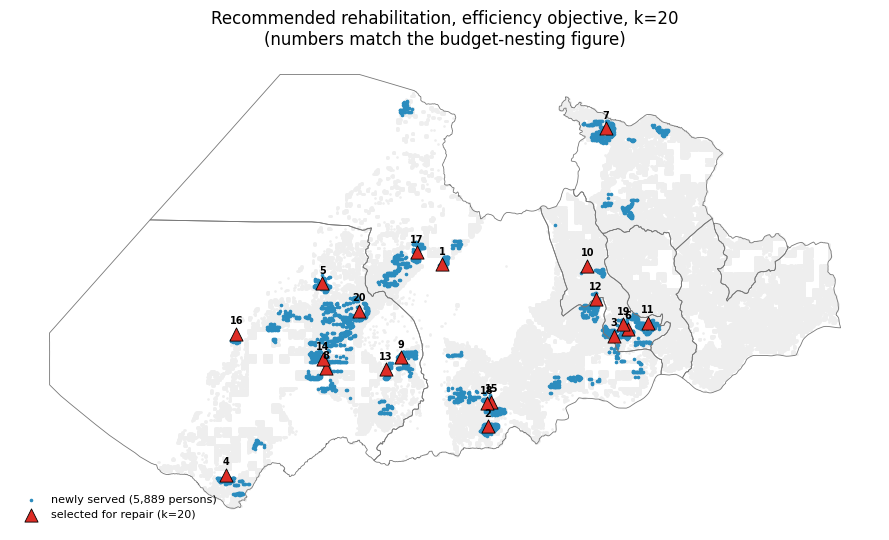


overlap between consecutive budgets:

=== efficiency ===
  k= 5 -> k=10: 5/5 of the smaller budget's points carried forward (fully nested)
  k=10 -> k=20: 10/10 of the smaller budget's points carried forward (fully nested)

=== equity ===
  k= 5 -> k=10: 5/5 of the smaller budget's points carried forward (fully nested)
  k=10 -> k=20: 10/10 of the smaller budget's points carried forward (fully nested)


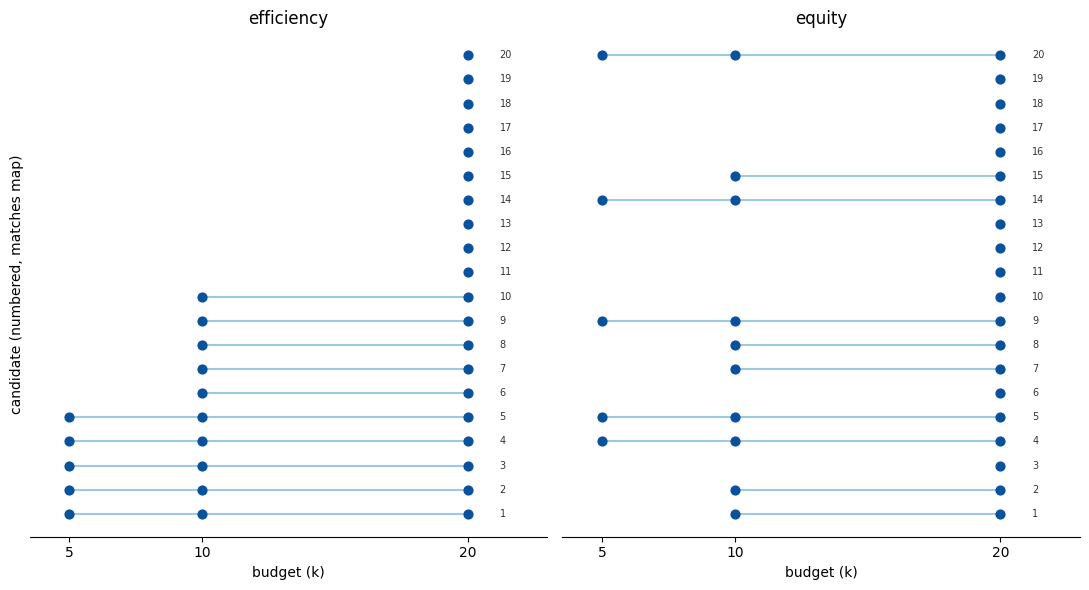


20 candidates numbered 1-20, saved to appendix_selection_numbered.csv
 fig_no district parish_village  capacity present_at_k      lat       lon
      1  Kikuube        Kabwoya     300.0      5,10,20 1.339107 30.981293
      2  Kikuube        Kabwoya     300.0      5,10,20 1.160839 31.031169
      3  Kikuube   Kiziranfumbi     300.0      5,10,20 1.260184 31.169785
      4  Kikuube      Kyangwali     300.0      5,10,20 1.107989 30.743996
      5  Kikuube      Kyangwali     300.0      5,10,20 1.318093 30.849600
      6  Kikuube   Kiziranfumbi     300.0        10,20 1.267808 31.184918
      7  Kikuube        Bugambe     300.0        10,20 1.488134 31.161363
      8  Kikuube      Kyangwali     300.0        10,20 1.224565 30.853281
      9  Kikuube      Kyangwali     300.0        10,20 1.236546 30.935842
     10  Kikuube   Kiziranfumbi     300.0        10,20 1.337075 31.140518
     11  Kikuube   Kiziranfumbi     300.0           20 1.274796 31.207033
     12  Kikuube   Kiziranfumbi     300.0

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import ast
df = pd.read_csv(SOLUTIONS)
df["chosen"] = df.chosen.apply(ast.literal_eval)

# --- solve k=20, efficiency objective ---
eff20_cell, _, eff20_chosen = solve_with_alloc(20, np.ones(nD))
gain_cell = eff20_cell - base_cell

# --- shared numbering: order by first appearance across k=5,10,20, then id ---
# this makes the numbers on the map identical to the numbers on the nesting plot
sets_by_k = {k: set(df[(df.k == k) & (df.objective == "efficiency")].chosen.iloc[0])
            for k in K_LIST}
all_pts = sorted(set.union(*sets_by_k.values()))
first_k = {p: min(k for k in K_LIST if p in sets_by_k[k]) for p in all_pts}
ordered = sorted(all_pts, key=lambda p: (first_k[p], p))
num_of = {p: i + 1 for i, p in enumerate(ordered)}   # candidate id -> figure number 1..N

# --- map: k=20 selection, numbered ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(demand.lon, demand.lat, c="#eeeeee", s=0.8)
m = gain_cell > 0.5
ax.scatter(demand.lon[m], demand.lat[m], c="#2b8cbe", s=2.5,
           label=f"newly served ({gain_cell.sum():,.0f} persons)")
sub_g.boundary.plot(ax=ax, color="#777", linewidth=0.6)

sel = cand.iloc[eff20_chosen].copy()
sel["fig_no"] = [num_of[j] for j in eff20_chosen]
ax.scatter(sel["#lon_deg"], sel["#lat_deg"], marker="^", s=90,
           c="#de2d26", edgecolor="black", linewidth=0.6, zorder=5,
           label=f"selected for repair (k=20)")
for _, r in sel.iterrows():
    ax.annotate(str(r.fig_no), (r["#lon_deg"], r["#lat_deg"]),
                textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=7, fontweight="bold", zorder=6)

ax.legend(loc="lower left", fontsize=8, frameon=False)
ax.set_title("Recommended rehabilitation, efficiency objective, k=20\n"
             "(numbers match the budget-nesting figure)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG / "fig_selection_k20_numbered.png", dpi=300, bbox_inches="tight")
plt.show()

# --- nesting plot, same numbering, both objectives ---
print("\noverlap between consecutive budgets:")
for obj in ("efficiency", "equity"):
    sets = {k: set(df[(df.k == k) & (df.objective == obj)].chosen.iloc[0])
            for k in K_LIST}
    print(f"\n=== {obj} ===")
    ks = sorted(sets)
    for i in range(len(ks) - 1):
        a, b = ks[i], ks[i + 1]
        shared = len(sets[a] & sets[b])
        print(f"  k={a:2d} -> k={b:2d}: {shared}/{a} of the smaller "
              f"budget's points carried forward "
              f"({'fully nested' if shared == a else 'not nested'})")

fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
for ax, obj in zip(axes, ("efficiency", "equity")):
    sets = {k: set(df[(df.k == k) & (df.objective == obj)].chosen.iloc[0])
            for k in K_LIST}
    # use the SAME numbering as the map (based on efficiency's first-appearance order)
    pts_here = sorted(set.union(*sets.values()), key=lambda p: num_of.get(p, 999))
    for p in pts_here:
        ks_present = sorted(k for k in K_LIST if p in sets[k])
        yi = num_of.get(p, len(ordered) + 1)
        ax.plot([ks_present[0], ks_present[-1]], [yi, yi],
                color="#9ecae1", linewidth=1.5, zorder=0)
        for k in ks_present:
            ax.scatter(k, yi, s=40, c="#08519c", zorder=2)
        ax.text(K_LIST[-1] + 1.2, yi, str(num_of.get(p, "?")),
                va="center", fontsize=7, color="#333")
    ax.set_xticks(K_LIST)
    ax.set_xlim(K_LIST[0] - 1.5, K_LIST[-1] + 3)
    ax.set_yticks([])
    ax.set_xlabel("budget (k)")
    ax.set_title(obj)
    ax.spines[["top", "right", "left"]].set_visible(False)
axes[0].set_ylabel("candidate (numbered, matches map)")
plt.tight_layout()
plt.savefig(FIG / "fig_budget_nesting_numbered.png", dpi=300, bbox_inches="tight")
plt.show()

# --- appendix table linking figure numbers to real locations ---
app = cand.iloc[ordered].copy()
app.insert(0, "fig_no", [num_of[p] for p in ordered])
app["at_k_efficiency"] = [",".join(str(k) for k in K_LIST if p in sets_by_k[k])
                          for p in ordered]
app_out = app[["fig_no", "#clean_adm2", "#clean_adm4", "usage_capacity",
              "at_k_efficiency", "#lat_deg", "#lon_deg"]]
app_out.columns = ["fig_no", "district", "parish_village", "capacity",
                   "present_at_k", "lat", "lon"]
app_out.to_csv(OUT / "appendix_selection_numbered.csv", index=False)
print(f"\n{len(app_out)} candidates numbered 1-{len(app_out)}, saved to appendix_selection_numbered.csv")
print(app_out.to_string(index=False))

## 7. Results

In [14]:
df = pd.DataFrame(records)
print(df[["k", "objective", "status", "served", "gain",
          "capacity_selected", "seconds"]]
      .to_string(index=False, formatters={
          "served": "{:,.0f}".format, "gain": "{:,.0f}".format,
          "capacity_selected": "{:,.0f}".format}))

print("\noverlap between the two objectives")
for K in K_LIST:
    e = set(df[(df.k == K) & (df.objective == "efficiency")].chosen.iloc[0])
    q = set(df[(df.k == K) & (df.objective == "equity")].chosen.iloc[0])
    print(f"  k={K:3d}: {len(e & q)} of {K} points shared")

 k  objective  status  served  gain capacity_selected  seconds
 5 efficiency Optimal 172,638 1,500             1,500       66
 5     equity Optimal 172,638 1,500             1,500       75
10 efficiency Optimal 174,138 3,000             3,000       75
10     equity Optimal 174,138 3,000             3,000       98
20 efficiency Optimal 177,027 5,889             5,950      125
20     equity Optimal 177,027 5,889             5,950      125

overlap between the two objectives
  k=  5: 2 of 5 points shared
  k= 10: 7 of 10 points shared
  k= 20: 20 of 20 points shared


k= 5  O1max=172,638.0  O2max=29,016.0  [144s]
  q=0.00  Optimal     O1n=1.0000  O2n=1.0000  dist=0.0000  [216s]
  q=0.25  Optimal     O1n=1.0000  O2n=1.0000  dist=0.0000  [289s]
  q=0.50  Optimal     O1n=1.0000  O2n=1.0000  dist=0.0000  [353s]
  q=0.75  Optimal     O1n=1.0000  O2n=1.0000  dist=0.0000  [428s]
  q=1.00  Optimal     O1n=1.0000  O2n=0.9997  dist=0.0003  [446s]
  self-check k=5: q=1 gives O1n=1.0000 PASS, q=0 gives O2n=1.0000 PASS

k=10  O1max=174,138.0  O2max=29,269.5  [617s]
  q=0.00  Optimal     O1n=1.0000  O2n=1.0000  dist=0.0000  [713s]
  q=0.25  Optimal     O1n=1.0000  O2n=1.0000  dist=0.0000  [810s]
  q=0.50  Optimal     O1n=1.0000  O2n=1.0000  dist=0.0000  [885s]
  q=0.75  Optimal     O1n=1.0000  O2n=1.0000  dist=0.0000  [982s]
  q=1.00  Optimal     O1n=1.0000  O2n=0.9997  dist=0.0003  [1040s]
  self-check k=10: q=1 gives O1n=1.0000 PASS, q=0 gives O2n=1.0000 PASS

k=20  O1max=177,027.3  O2max=29,749.8  [1290s]
  q=0.00  Optimal     O1n=1.0000  O2n=1.0000  dist=0.00

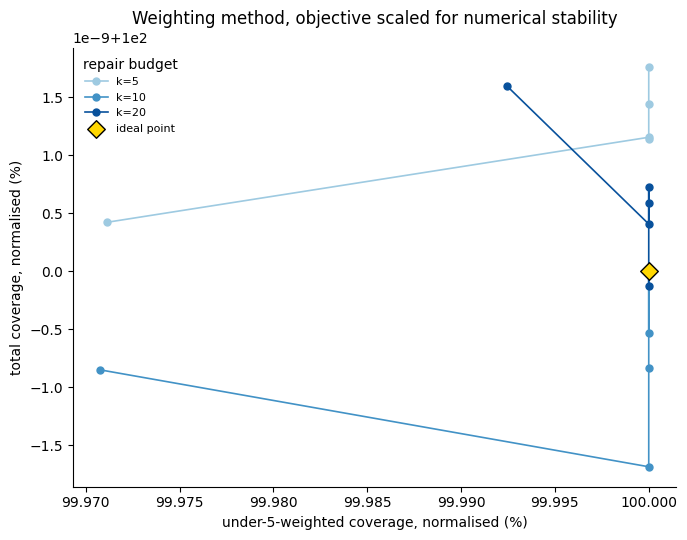

In [15]:
import numpy as np
import pandas as pd
import pulp
import matplotlib.pyplot as plt
import time

TOTAL_U5 = 64066
TOTAL_POP = pop.sum()
Q_STEPS = [0.0, 0.25, 0.5, 0.75, 1.0]

# After normalising, the objective coefficients are around 1/181461 ~ 5.5e-6.
# That is small enough to fall inside CBC's absolute tolerances: in the first
# run the solver returned "Optimal" after 0 iterations and 0 nodes, having
# accepted the first feasible solution without searching. Scaling the whole
# objective by a constant leaves the optimum unchanged but makes the
# differences between solutions visible to the solver.
SCALE = 1e6

def solve_scaled(K, q, o1_max=None, o2_max=None, time_limit=1800):
    p = pulp.LpProblem("CMCLP_weighted_scaled", pulp.LpMaximize)
    y = {j: pulp.LpVariable(f"y{j}", cat="Binary") for j in range(nC)}
    zc, zs = {}, {}
    for i in range(nD):
        for j in cov_c[i]: zc[(i, j)] = pulp.LpVariable(f"c{i}_{j}", lowBound=0)
        for j in cov_s[i]: zs[(i, j)] = pulp.LpVariable(f"s{i}_{j}", lowBound=0)

    a = 1.0 if o1_max is None else SCALE / o1_max
    b = 1.0 if o2_max is None else SCALE / o2_max
    p += (pulp.lpSum((q*a + (1-q)*b*w_u5[i]) * v for (i, j), v in zc.items())
          + pulp.lpSum((q*a + (1-q)*b*w_u5[i]) * v for (i, j), v in zs.items()))

    for i in range(nD):
        t = [zc[(i, j)] for j in cov_c[i]] + [zs[(i, j)] for j in cov_s[i]]
        if t: p += pulp.lpSum(t) <= pop[i]
    bc, bs = {}, {}
    for (i, j), v in zc.items(): bc.setdefault(j, []).append(v)
    for (i, j), v in zs.items(): bs.setdefault(j, []).append(v)
    for j in range(nC):
        if j in bc: p += pulp.lpSum(bc[j]) <= capC[j]*y[j]
    for j in range(nS):
        if j in bs: p += pulp.lpSum(bs[j]) <= capS[j]
    p += pulp.lpSum(y.values()) <= K

    p.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit))
    served = sum(v.value() for v in zc.values()) + sum(v.value() for v in zs.values())
    u5 = (sum(w_u5[i]*v.value() for (i, j), v in zc.items())
          + sum(w_u5[i]*v.value() for (i, j), v in zs.items()))
    chosen = sorted(j for j in range(nC) if y[j].value() and y[j].value() > 0.5)
    return pulp.LpStatus[p.status], served, u5, chosen

results_scaled = []
t0 = time.time()
for K in K_LIST:
    _, o1_max, _, _ = solve_scaled(K, q=1.0)
    _, _, o2_max, _ = solve_scaled(K, q=0.0)
    print(f"k={K:2d}  O1max={o1_max:,.1f}  O2max={o2_max:,.1f}  [{time.time()-t0:.0f}s]")

    for q in Q_STEPS:
        st, served, u5, chosen = solve_scaled(K, q, o1_max=o1_max, o2_max=o2_max)
        o1n, o2n = served / o1_max, u5 / o2_max
        dist = np.sqrt((1 - o1n)**2 + (1 - o2n)**2)
        results_scaled.append(dict(k=K, q=q, status=st, served=served, u5=u5,
                                   o1_norm=o1n, o2_norm=o2n, dist_to_ideal=dist,
                                   chosen=chosen))
        print(f"  q={q:.2f}  {st:10s}  O1n={o1n:.4f}  O2n={o2n:.4f}  "
              f"dist={dist:.4f}  [{time.time()-t0:.0f}s]")

    # self-check: at q=1 the objective reduces to O1 alone, so O1n must be 1.0000;
    # at q=0 it reduces to O2 alone, so O2n must be 1.0000. Anything else means
    # the solve did not reach the optimum the anchors already proved attainable.
    r1 = [r for r in results_scaled if r["k"] == K and r["q"] == 1.0][0]
    r0 = [r for r in results_scaled if r["k"] == K and r["q"] == 0.0][0]
    ok1 = abs(r1["o1_norm"] - 1.0) < 1e-4
    ok0 = abs(r0["o2_norm"] - 1.0) < 1e-4
    print(f"  self-check k={K}: q=1 gives O1n=1.0000 {'PASS' if ok1 else 'FAIL'}, "
          f"q=0 gives O2n=1.0000 {'PASS' if ok0 else 'FAIL'}\n")

res_scaled = pd.DataFrame(results_scaled)
res_scaled.to_csv(OUT / "roman_5point_scaled.csv", index=False)

print("=== summary per k ===")
for K in K_LIST:
    sub_r = res_scaled[res_scaled.k == K]
    comp = sub_r.loc[sub_r.dist_to_ideal.idxmin()]
    print(f"k={K:2d}: max dist across q = {sub_r.dist_to_ideal.max():.4f}, "
          f"compromise at q={comp.q:.2f}")

print("\n=== selection overlap ===")
for K in K_LIST:
    sub_r = res_scaled[res_scaled.k == K]
    eq_set = set(sub_r[sub_r.q == 0.0].chosen.iloc[0])
    eff_set = set(sub_r[sub_r.q == 1.0].chosen.iloc[0])
    print(f"k={K:2d}: equity vs efficiency {len(eq_set & eff_set)}/{K} shared")

fig, ax = plt.subplots(figsize=(7, 5.5))
colors = {5: "#9ecae1", 10: "#4292c6", 20: "#08519c"}
for K in K_LIST:
    s = res_scaled[res_scaled.k == K].sort_values("q")
    ax.plot(s.o2_norm*100, s.o1_norm*100, marker="o", markersize=5,
            color=colors[K], linewidth=1.2, label=f"k={K}")
ax.scatter([100], [100], marker="D", s=80, color="gold", edgecolor="black",
           zorder=5, label="ideal point")
ax.set_xlabel("under-5-weighted coverage, normalised (%)")
ax.set_ylabel("total coverage, normalised (%)")
ax.set_title("Weighting method, objective scaled for numerical stability")
ax.legend(fontsize=8, frameon=False, title="repair budget")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG / "fig_roman_5point_scaled.png", dpi=300, bbox_inches="tight")
plt.show()

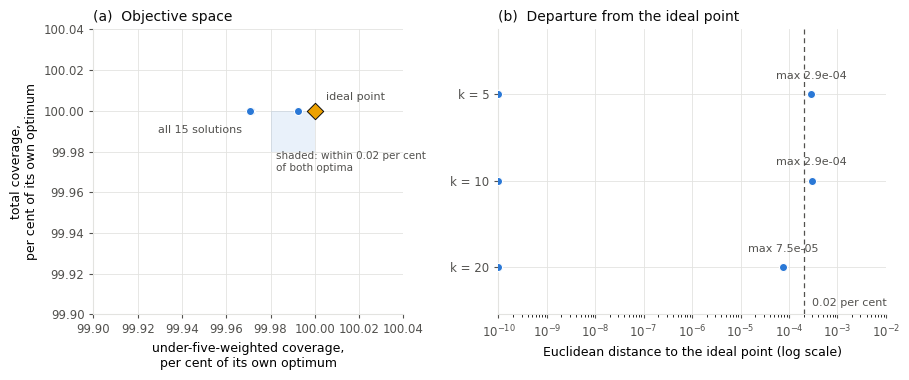

 k          q    o1_norm    o2_norm  dist_to_ideal
 5 0.00000000 1.00000000 1.00000000     0.00000000
 5 0.25000000 1.00000000 1.00000000     0.00000000
 5 0.50000000 1.00000000 1.00000000     0.00000000
 5 0.75000000 1.00000000 1.00000000     0.00000000
 5 1.00000000 1.00000000 0.99971125     0.00028875
10 0.00000000 1.00000000 1.00000000     0.00000000
10 0.25000000 1.00000000 1.00000000     0.00000000
10 0.50000000 1.00000000 1.00000000     0.00000000
10 0.75000000 1.00000000 1.00000000     0.00000000
10 1.00000000 1.00000000 0.99970770     0.00029230
20 0.00000000 1.00000000 1.00000000     0.00000000
20 0.25000000 1.00000000 1.00000000     0.00000000
20 0.50000000 1.00000000 1.00000000     0.00000000
20 0.75000000 1.00000000 1.00000000     0.00000000
20 1.00000000 1.00000000 0.99992457     0.00007543


In [16]:
# ---------------------------------------------------------------------------
# Figure: the weighting sweep collapses to the ideal point.
#
# Replaces the earlier plot. Two changes of substance:
#   (a) matplotlib's offset notation is switched off, so the tick labels read as
#       percentages rather than as "1e-9+1e2" and the reader is not asked to
#       decode an exponent;
#   (b) the spread is reported on its own axis, because in objective space the
#       points are indistinguishable and that is the finding, not a defect.
# One series, one colour throughout: the budget is carried by position, not hue.
# ---------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
 
SERIES = "#2a78d6"
IDEAL  = "#eda100"
INK    = "#0b0b0b"
MUTED  = "#52514e"
GRID   = "#e3e3e0"
 
res = res_scaled.copy()
res["o1_pct"] = res.o1_norm * 100
res["o2_pct"] = res.o2_norm * 100
 
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(9.2, 3.9), gridspec_kw={"width_ratios": [1, 1.25]})
 
# ---- (a) objective space, read at a scale a person can hold in mind --------
LO, HI = 99.90, 100.04
axL.add_patch(plt.Rectangle((100 - 0.02, 100 - 0.02), 0.02, 0.02,
                            facecolor=SERIES, alpha=0.10, zorder=1,
                            linewidth=0))
axL.scatter(res.o2_pct, res.o1_pct, s=34, facecolor=SERIES,
            edgecolor="white", linewidth=0.8, zorder=3)
axL.scatter([100], [100], marker="D", s=70, facecolor=IDEAL,
            edgecolor=INK, linewidth=0.7, zorder=4)
axL.annotate("ideal point", (100, 100), xytext=(8, 8),
             textcoords="offset points", fontsize=8, color=MUTED, ha="left")
axL.annotate("all 15 solutions", (res.o2_pct.min(), 100),
             xytext=(-6, -16), textcoords="offset points", fontsize=8,
             color=MUTED, ha="right")
axL.annotate("shaded: within 0.02 per cent\nof both optima", (100 - 0.02, 100 - 0.02),
             xytext=(4, -14), textcoords="offset points", fontsize=7.5,
             color=MUTED, ha="left")
 
axL.set_xlim(LO, HI); axL.set_ylim(LO, HI)
axL.ticklabel_format(useOffset=False, style="plain")
axL.xaxis.set_major_formatter(FormatStrFormatter("%.2f"))
axL.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
axL.set_xlabel("under-five-weighted coverage,\nper cent of its own optimum", fontsize=9)
axL.set_ylabel("total coverage,\nper cent of its own optimum", fontsize=9)
axL.set_title("(a)  Objective space", fontsize=10, loc="left", color=INK)
 
# ---- (b) how far from the ideal point, on an axis that can show it ---------
FLOOR = 1e-10          # exact zeros are drawn on the axis floor
rows = {5: 2, 10: 1, 20: 0}
for k, y in rows.items():
    s = res[res.k == k]
    x = s.dist_to_ideal.clip(lower=FLOOR)
    axR.scatter(x, np.full(len(s), y), s=34,
                facecolor=SERIES, edgecolor="white", linewidth=0.8, zorder=3)
    axR.annotate(f"max {s.dist_to_ideal.max():.1e}", (x.max(), y),
                 xytext=(0, 11), textcoords="offset points", fontsize=8,
                 color=MUTED, ha="center")
 
axR.set_yticks(list(rows.values()))
axR.set_yticklabels([f"k = {k}" for k in rows])
axR.set_ylim(-0.55, 2.75)
axR.set_xscale("log")
axR.set_xlim(1e-10, 1e-2)
axR.axvline(2e-4, color=MUTED, linestyle=(0, (4, 3)), linewidth=0.9, zorder=2)
axR.annotate("0.02 per cent", (2e-4, -0.42), xytext=(6, 0),
             textcoords="offset points", fontsize=8, color=MUTED, va="center")
axR.set_xlabel("Euclidean distance to the ideal point (log scale)", fontsize=9)
axR.set_title("(b)  Departure from the ideal point", fontsize=10, loc="left",
              color=INK)
 
for ax in (axL, axR):
    ax.grid(True, color=GRID, linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8.5, length=3)
 
plt.tight_layout()
plt.savefig(FIG / "fig_weighting_collapse.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
 
print(res[["k", "q", "o1_norm", "o2_norm", "dist_to_ideal"]]
      .to_string(index=False, float_format=lambda v: f"{v:.8f}"))

## 8. Is capacity binding

If the gain equals the capacity of the selected points then every repaired point
fills up, and which points were chosen made no difference to the total. A ratio
below one means the constraint has begun to slacken and the choice starts to
matter.

In [17]:
eff = df[df.objective == "efficiency"].sort_values("k")
print("gain against the capacity ceiling\n")
print(f"{'k':>5}{'gain':>12}{'capacity of selected':>24}{'ratio':>9}")
for _, r in eff.iterrows():
    print(f"{r.k:>5.0f}{r.gain:>12,.0f}{r.capacity_selected:>24,.0f}"
          f"{r.gain / r.capacity_selected:>9.2f}")

gain against the capacity ceiling

    k        gain    capacity of selected    ratio
    5       1,500                   1,500     1.00
   10       3,000                   3,000     1.00
   20       5,889                   5,950     0.99


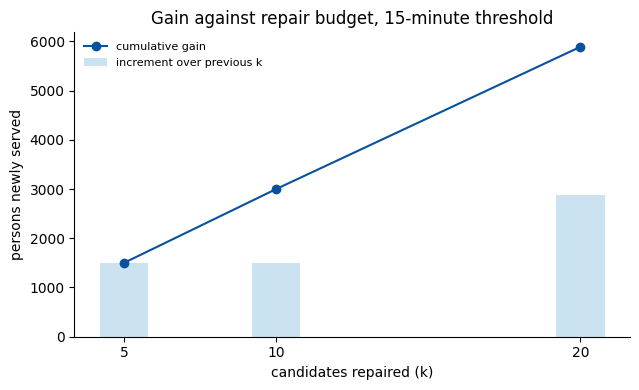

In [18]:
import matplotlib.pyplot as plt

eff = df[df.objective == "efficiency"].sort_values("k")
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(eff.k, eff.gain, marker="o", color="#08519c", label="cumulative gain")
ax.bar(eff.k, eff.gain.diff().fillna(eff.gain), width=1.6, alpha=0.35,
       color="#6baed6", label="increment over previous k")
ax.set_xlabel("candidates repaired (k)")
ax.set_ylabel("persons newly served")
ax.set_xticks(list(eff.k))
ax.legend(frameon=False, fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Gain against repair budget, 15-minute threshold")
plt.tight_layout()
plt.savefig(FIG / "fig_gain_by_k.png", dpi=300, bbox_inches="tight")
plt.show()

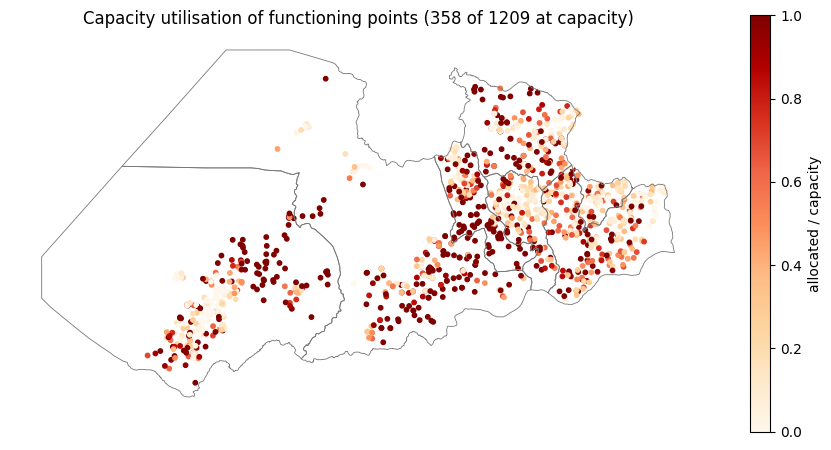

In [19]:
# utilisation of functioning points at the baseline
util = np.divide(base_load, capS, out=np.zeros_like(base_load), where=capS > 0)

fig, ax = plt.subplots(figsize=(9, 5.5))
sub_g.boundary.plot(ax=ax, color="#777", linewidth=0.6)
sc = ax.scatter(supp["#lon_deg"], supp["#lat_deg"], c=util, s=10,
                cmap="OrRd", vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label="allocated / capacity", shrink=0.8)
full = (util >= 0.999).sum()
ax.set_title(f"Capacity utilisation of functioning points "
             f"({full} of {nS} at capacity)")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG / "fig_capacity_pressure.png", dpi=300, bbox_inches="tight")
plt.show()

Compare against the recorded run: a baseline of 175,639 served, and gains of
1,500 at k=5, 3,000 at k=10 and 5,822 at k=20. The first two equal 300 times k
exactly, which is what the ratio in the last cell is for.